## Counts of extreme events per year 

(Fig. 4 in Garcia-Mesa et al.2025)

## ROC Curves

This block generates **ROC curves** (Receiver Operating Characteristic) for each site, showing how the model distinguishes between extremes (positive class) and non-extremes (negative class).  

- **Input:** Model probabilities and predictions per site, stored in dictionaries.  
- **Process:**  
  1. For each site, predictions are filtered at multiple confidence thresholds.  
  2. ROC curves are computed using the true labels and predicted probabilities.  
  3. Each threshold is plotted in a different shade of blue (higher confidence → darker).  
  4. The 0.5 cutoff point is highlighted on each curve.  
- **Output:** A grid of ROC curves (2×3), one per site, with multiple curves per site corresponding to different confidence levels.

In [2]:
# Library and module imports
import os
import sys
import torch
import hydra
from omegaconf import OmegaConf
from datetime import datetime
import numpy as np
import pandas as pd
import random
import pickle  # Added missing import
from pathlib import Path
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import balanced_accuracy_score
from quantifydrivers import machine_learning
import matplotlib.pyplot as plt
import yaml
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import xarray as xr
import torch.nn as nn
import torch.optim as optim
from datetime import datetime
from hydra import initialize, compose
from omegaconf import DictConfig, OmegaConf
import shap
from sklearn.metrics import roc_curve, auc

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"*** Device set to: {device} ***")

from quantifydrivers.train_and_shap.config_schema import validate_schema
from quantifydrivers.train_and_shap.dataloading_script import build_datasets_and_loaders


try:
    from hydra.core.global_hydra import GlobalHydra
    if GlobalHydra.instance().is_initialized():
        GlobalHydra.instance().clear()
except Exception as e:
    print(f"Hydra Error: {e}")

rel_config_path = "../train_and_shap/conf"

with initialize(version_base=None, config_path=rel_config_path):
        cfg = compose(config_name="config",overrides=[])
try:
        validated_cfg = validate_schema(cfg)
        print("Config Validation Passed!")
except Exception as e:
        print("Config Vlidation Failed.")
try:
    torch.use_deterministic_algorithms(True)
    print("Using deterministic algorithms.")
except Exception as e:
    print(f"Could not enforce deterministic algorithms: {e}")

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False

*** Device set to: cpu ***
Config Validation Passed!
Using deterministic algorithms.


Config Validation Passed!
Doing site: cordoba
Mean counts 1950-2000 for cordoba is : 10.333333333333334
Config Validation Passed!
Doing site: lyon
Mean counts 1950-2000 for lyon is : 9.958333333333334
Config Validation Passed!
Doing site: hannover
Mean counts 1950-2000 for hannover is : 10.270833333333334
Config Validation Passed!
Doing site: stockholm
Mean counts 1950-2000 for stockholm is : 10.208333333333334
Config Validation Passed!
Doing site: belgrado
Mean counts 1950-2000 for belgrado is : 10.395833333333334
Config Validation Passed!
Doing site: marrakech
Mean counts 1950-2000 for marrakech is : 9.9375


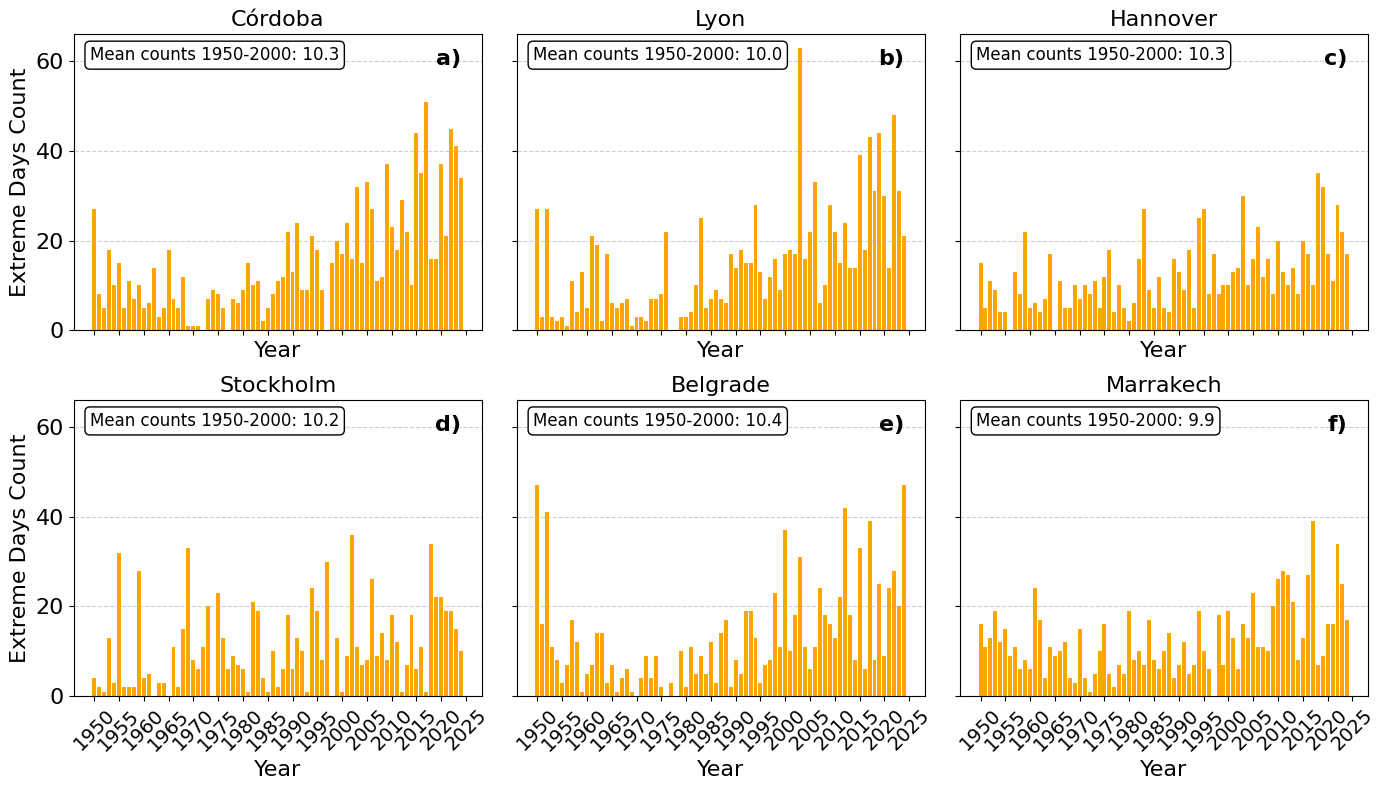

In [5]:

sites = ['cordoba','lyon','hannover','stockholm','belgrado','marrakech']

sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade','Marrakech']

# Create subplots with shared axes
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
axes = axes.flatten()

date_range = pd.date_range(start=validated_cfg.dataset.start_date_train, end=validated_cfg.dataset.end_date_test, freq='D')
filtered_dates = np.array([
    d for d in date_range
    if d.month in [6, 7, 8] and not (d.year == 2024 and d.month == 7 and d.day == 31)
])

file_CO2 = os.path.join(validated_cfg.paths.base_folder, "aux", "co2")
percentile = validated_cfg.percentile
variables = ['swvl1','swvl2','swvl3']

for i, site in enumerate(sites):

    # Initialize & validate config
    with initialize(version_base=None, config_path=rel_config_path):
        cfg = compose(config_name="config",overrides=[f"site={site}"])
    try:
        validated_cfg = validate_schema(cfg)
        print("Config Validation Passed!")

    except Exception as e:
        print("Config Validation Failed or validate_schema not imported.")
    
    print(f"Doing site: {site}")
    #file_local_scale =os.path.join(validated_cfg.paths.base_folder, "era5land", validated_cfg.percentile, validated_cfg.site.name, f"{validated_cfg.percentile}_{validated_cfg.site.name}_lagged_standarized_anomalies_and_extreme_detection.nc")
    file_local_scale =os.path.join(validated_cfg.paths.base_folder, "era5land", validated_cfg.percentile, validated_cfg.site.name)
    dataset = machine_learning.LocalScale_Dataset_extremes_location_swvl_averaged_including_CO2(file_path=file_local_scale,
                                                                                                start_date=validated_cfg.dataset.start_date_train,
                                                                                                end_date=validated_cfg.dataset.end_date_test,
                                                                                                months=validated_cfg.dataset.months,
                                                                                                file_CO2=file_CO2,
                                                                                                variables=validated_cfg.dataset.variables_era5land,)

    y_true = dataset.labels

    df = pd.DataFrame({
        'date': filtered_dates,
        'label': y_true
    })
    df['year'] = pd.DatetimeIndex(df['date']).year
    counts = df[df['label'] == 1].groupby('year').size()
    counts = counts.groupby(counts.index).sum()
    counts = counts.sort_index()
    counts.index = counts.index.astype(int)
    mean_counts = np.mean(counts[:48])
    print(f"Mean counts 1950-2000 for {site} is : {mean_counts}")

    ax = axes[i]
    ax.clear()
    #counts.plot(kind='bar', ax=ax, color='orange')
    ax.bar(counts.index, counts.values, color='orange', width=0.8)

    ax.set_title(sites_title[i],fontsize=16)
    ax.set_xlabel('Year', fontsize=16)

    ax.text(0.95, 0.95, f'{chr(97+i)})',  # 97 is ASCII for 'a'
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            va='top',
            ha='right')

    # Only set ylabel for leftmost plots
    if i % 3 == 0:
        ax.set_ylabel('Extreme Days Count', fontsize=16)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))  # every 5 years
    ax.tick_params(axis='x', labelsize=14)
    for tick in ax.get_xticklabels():

        tick.set_rotation(45)

    ax.tick_params(axis='y', labelsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    ax.text(0.04, 0.96,
               f"Mean counts 1950-2000: {mean_counts:.1f}",
               transform=ax.transAxes,
               fontsize=12,
               verticalalignment='top',
               bbox=dict(boxstyle="round", facecolor="white"))

    ax.set_ylim(0,66)


#plt.suptitle("Yearly Extreme Count of the different Locations",fontsize=15)
plt.tight_layout()
#plt.savefig(os.path.join(validated_cfg.paths.results_dir, "/plots/90p_yearly_counts_extremes_locations.pdf"))
plt.show()

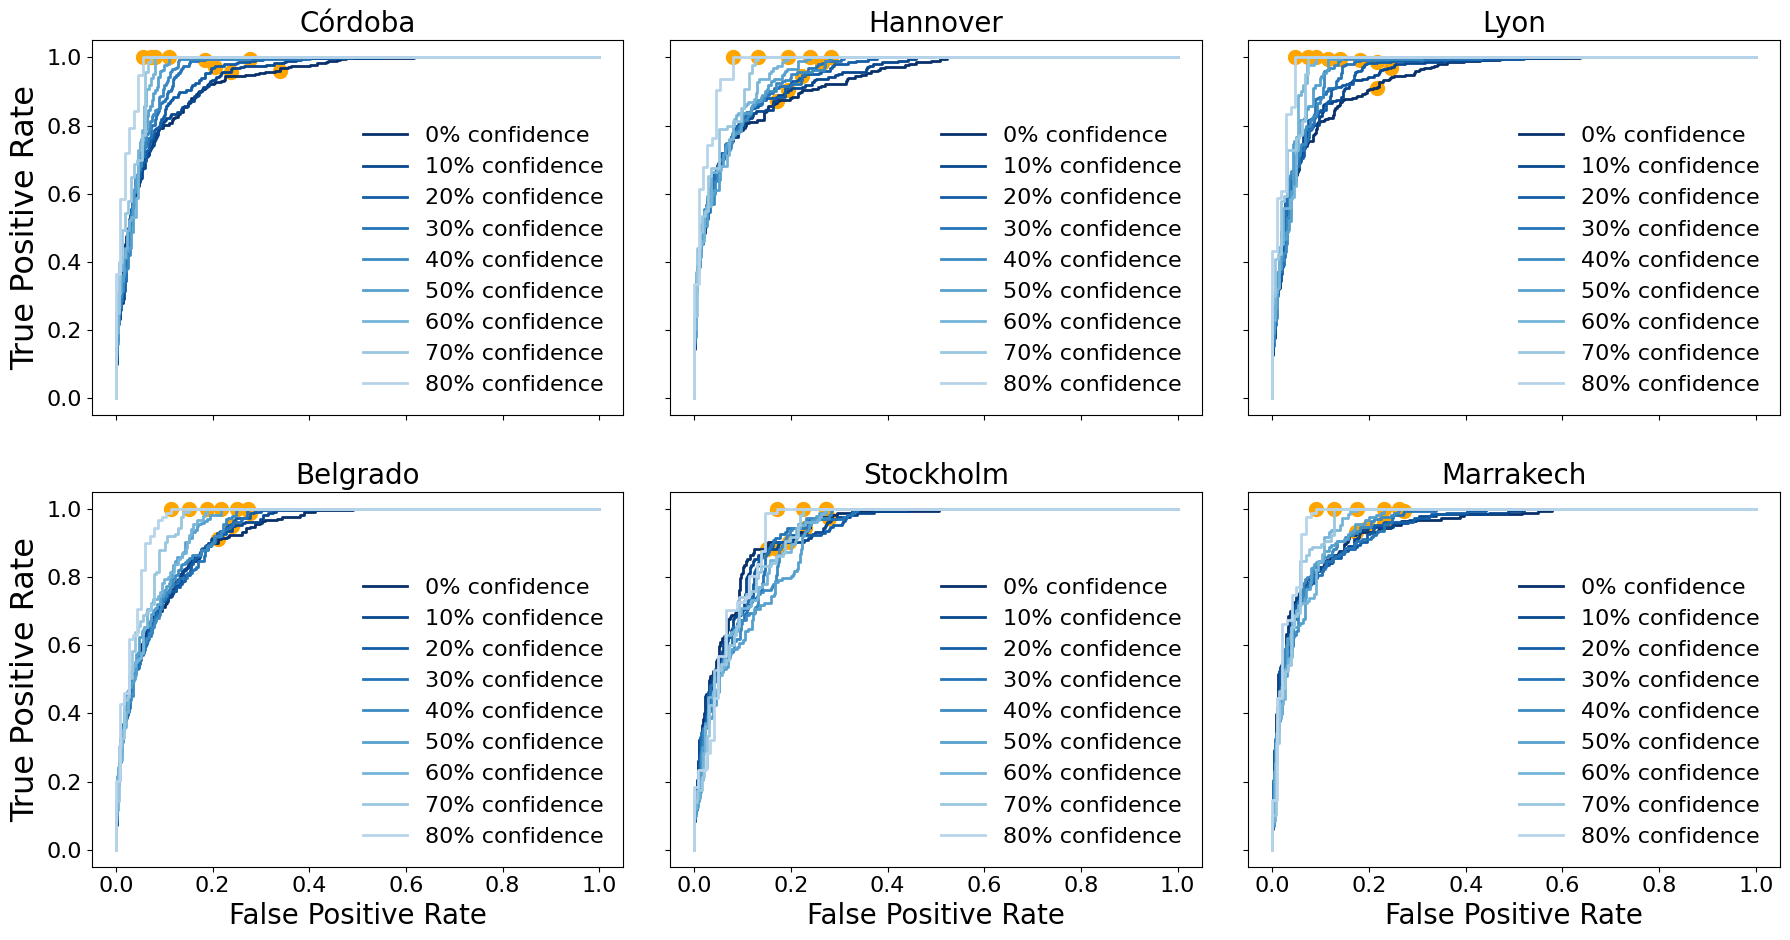

In [8]:
number_lags = 3  # (used in figure save name)

# Sites to evaluate
sites = ['cordoba','hannover','lyon','belgrado','stockholm','marrakech']
sites_title = ['Córdoba','Hannover','Lyon','Belgrado','Stockholm','Marrakech']

# Confidence thresholds (percentiles) to test
percentages = [50, 55, 60, 65, 70, 75, 80, 85, 90]
percentile = validated_cfg.percentile

# ------------------------------------------------------------------------------------------
# Build color map for confidence levels (higher confidence → darker blue)
# ------------------------------------------------------------------------------------------
norm = np.linspace(1, 0.3, len(percentages))   # Scale values for colormap
colors = [cm.Blues(n) for n in norm]           # Generate color shades
percentage_color_map = dict(zip(percentages, colors))  # Map each percentile to a color

# ------------------------------------------------------------------------------------------
# Create subplot grid for ROC curves (2 rows × 3 columns, shared axes for comparability)
# ------------------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex='col', sharey='row')
axes = axes.flatten()

j = 0  # Subplot index counter

# Loop over each site
for count_site, site in enumerate(sites):

    main_path = os.path.join(validated_cfg.paths.results_dir,'txt')

    # Load stored predictions and probabilities
    with open(os.path.join(main_path, f"{percentile}_results_data_{site}.pkl"), 'rb') as f:
        dict_results = pickle.load(f)

    # --------------------------------------------------------------------------------------
    # Loop over different confidence thresholds
    # --------------------------------------------------------------------------------------
    for value in percentages:

        out_probabilities = dict_results['out_probs_sites']  # Probabilities per class

        # Build mask: keep only samples above the selected confidence threshold
        mask = np.zeros_like(out_probabilities, dtype=bool)

        for i in range(out_probabilities.shape[1]):
            threshold = np.percentile(out_probabilities[:, i], value)
            mask[:, i] = out_probabilities[:, i] >= threshold

        mask_def = mask[:,0] | mask[:,1]  # Keep if confident in either class (0 or 1)

        # Extract true and predicted labels
        y_true, y_pred = dict_results['y_true_pred_pairs']
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        # Apply filtering
        y_true_filtered = y_true[mask_def]
        y_pred_filtered = y_pred[mask_def]

        # ----------------------------------------------------------------------------------
        # Compute ROC curve and AUC (area under curve)
        # ----------------------------------------------------------------------------------
        fpr, tpr, thresholds = roc_curve(
            y_true_filtered,
            out_probabilities[:, 1][mask_def]  # Probabilities for positive class
        )
        roc_auc = auc(fpr, tpr)  # AUC = overall discriminative ability

        # Plot ROC curve for this confidence level
        axes[j].plot(
            fpr, tpr,
            color=percentage_color_map[value],
            lw=2,
            label=f"{(value-50)*2}% confidence"
        )

        # Highlight cutoff point (threshold ≈ 0.5)
        cutoff = 0.5
        index = (np.abs(thresholds - cutoff)).argmin()
        axes[j].scatter(
            fpr[index], tpr[index],
            marker='o' if cutoff == 0.5 else '^',
            color='orange', s=100
        )

        # Debug output (unused since value never equals 25 in this loop)
        if value == 25:
            print(site)
            print(roc_auc)

    # --------------------------------------------------------------------------------------
    # Format subplot
    # --------------------------------------------------------------------------------------
    axes[j].set_title(sites_title[count_site], fontsize=20)
    axes[j].tick_params(axis='both', labelsize=16)
    axes[j].legend(frameon=False, loc="lower right", fontsize=16)

    j += 1

# ------------------------------------------------------------------------------------------
# Global labels and layout
# ------------------------------------------------------------------------------------------
for m in range(3, 6):  # Bottom row x-axis labels
    axes[m].set_xlabel('False Positive Rate', fontsize=20)

axes[0].set_ylabel('True Positive Rate', fontsize=23)
axes[3].set_ylabel('True Positive Rate', fontsize=23)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3, w_pad=3)

# Save ROC curves figure
#plt.savefig(os.path.join(validated_cfg.paths.results_dir, f"/plots/95p_ROC_curves_Combinedmodel_{number_lags}lags.png"))


# Mean SHAP values

Code to reproduce figure 5 Garcia-Mesa et al. 2025

cordoba
Config Validation Passed!
dict_keys(['seed', 'site', 'percentile', 'hyperparameters', 'dataset', 'epoch_config', 'paths'])
0.0001 <class 'float'>
Loading hyperparameters for percentile: 90p
*** Checking hyperparameter file path: /gpfs/scratch/bsc32/bsc214253/quantifydrivershw/src/quantifydrivers/data_files/HYPMS_optimization_results/g500_1lag_cordoba_best_params_90p_with_testing_phase.txt ***
*** Hyperparameter file found for cordoba. Loading content... ***
*** Hyperparameters successfully parsed. ***
Loaded hyperparameters for cordoba: {'lr': 0.00025, 'w_decay': 0.019096, 'batch_size': 32, 'minority_weight_multiplier': 14.584998}
0.0001 <class 'float'>
Doing site: cordoba
*** Setting up file paths for site: cordoba ***
Finished site cordoba
hannover
Config Validation Passed!
dict_keys(['seed', 'site', 'percentile', 'hyperparameters', 'dataset', 'epoch_config', 'paths'])
0.0001 <class 'float'>
Loading hyperparameters for percentile: 90p
*** Checking hyperparameter file path: /g

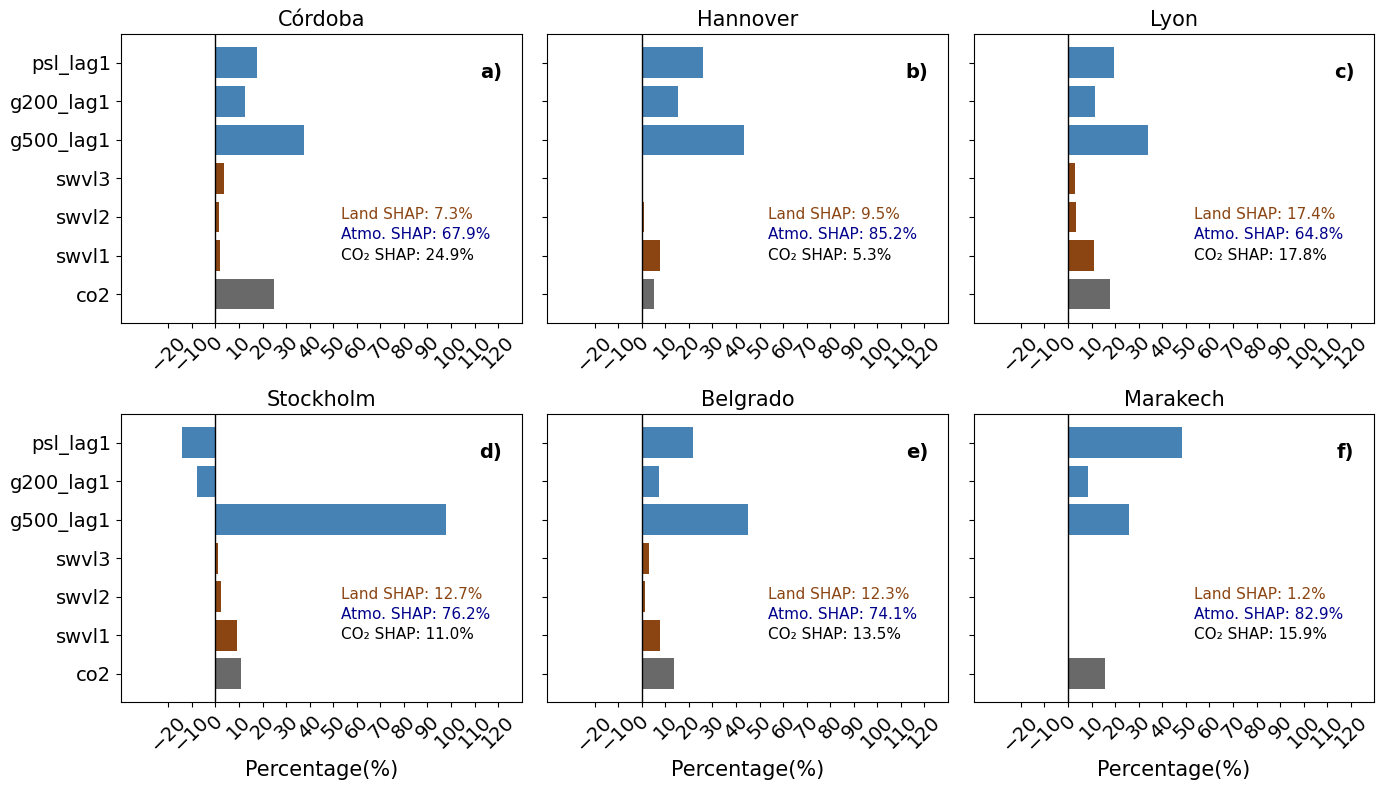

In [12]:
# Assuming these are your custom modules
from quantifydrivers import machine_learning

def draw_colored_text_block(ax, x, y, items):
    for i, (name, value, color) in enumerate(items):
        ax.text(x, y - i*0.07, f"{name}: {value:.1f}%", transform=ax.transAxes,
                fontsize=11, color=color, verticalalignment='top')

atmo_color = 'steelblue'
land_color = 'saddlebrown'
co2_color = 'dimgray'

sites = ['cordoba','hannover','lyon','stockholm','belgrado','marrakech']
#sites = ['cordoba','lyon','hannover','stockholm','belgrado','']

sites_title = ['Córdoba', 'Hannover', 'Lyon','Stockholm','Belgrado','Marakech']
#sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade']

# =====================================================================================
# Percentile Defition
percentile = '90p'
using_spei = False
scales_spei = ['30','90']
spei_spi = 'spei'
spei_spi_variable_mapping = {
    'spei': [f'spei_hg_{scale_spei}' for scale_spei in scales_spei],
    'spi': [f'spi_{scale_spei}' for scale_spei in scales_spei]
    }

spei_variables = spei_spi_variable_mapping[spei_spi] # Variable name in the dataset for SPEI
distribution = 'gamma'  # 'GEV' or 'gamma'

# =====================================================================================

# Combined Dataset and Dataloader
fig_bar,axes_bar = plt.subplots(2,3,figsize=(14,8), sharex='col', sharey='row')
axes_bar = axes_bar.flatten()

count_plot = 0

for s,site in enumerate(sites):

    print(f"{site}")

   # Initialize & validate config
    with initialize(version_base=None, config_path=rel_config_path):
        cfg = compose(config_name="config",overrides=[f"site={site}"])
    try:
        validated_cfg = validate_schema(cfg)
        print("Config Validation Passed!")

    except Exception as e:
        print("Config Validation Failed or validate_schema not imported.")
    # Create Generator and Seed everything
    g = torch.Generator()
    g.manual_seed(validated_cfg.seed)
    random.seed(validated_cfg.seed)
    np.random.seed(validated_cfg.seed)
    torch.manual_seed(validated_cfg.seed)

    datasets = build_datasets_and_loaders(configuration=validated_cfg, generator=g)

    combined_train_dataset = datasets['combined_train']
    combined_test_dataset = datasets['combined_test']
    test_dataset = datasets['test_dataset']
    test_features_era5 = datasets['test_era5']
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device("cpu")

    # Explainer data for SHAP

    explainer_indices = np.arange(0,len(combined_test_dataset),1)

    explain_nn = []
    explain_cnn = []

    for idx in explainer_indices:
        nn_input, cnn_input, labels = combined_test_dataset[idx]  # Adjust based on your dataset structure
        explain_nn.append(nn_input)
        explain_cnn.append(cnn_input)

    explain_nn = torch.stack(explain_nn,dim=0).to(device)
    explain_cnn = torch.stack(explain_cnn,dim=0).to(device)

    explain_data = [explain_nn, explain_cnn]

    # Load computed SHAP


    if using_spei:
        #with open(os.path.join(main_path_res, f'{variables_era5[0]}_swvl1_{percentile}_results_data_{site}.pkl'), 'rb') as f:
        with open(os.path.join(validated_cfg.paths.results_dir,f"txt/{percentile}_results_data_{validated_cfg.dataset.spei_spi}_{site}.pkl"), 'rb') as f:
            dict_results = pickle.load(f)
        #with open(os.path.join(main_path_shap, f'{variables_era5[0]}_swvl1_{percentile}_SHAP_results_{site}.pkl'), 'rb') as f:
        with open(os.path.join(validated_cfg.paths.results_dir,f"txt/{percentile}_shap_data_{validated_cfg.dataset.spei_spi}_{site}.pkl"), 'rb') as f:
            loaded_shap_dict = pickle.load(f)
    else:
        #with open(os.path.join(main_path_res, f'{variables_era5[0]}_swvl1_{percentile}_results_data_{site}.pkl'), 'rb') as f:
        with open(os.path.join(validated_cfg.paths.results_dir,f"txt/{percentile}_results_data_{site}.pkl"), 'rb') as f:
            dict_results = pickle.load(f)
        #with open(os.path.join(main_path_shap, f'{variables_era5[0]}_swvl1_{percentile}_SHAP_results_{site}.pkl'), 'rb') as f:
        with open(os.path.join(validated_cfg.paths.results_dir,f"txt/{percentile}_shap_data_{site}.pkl"), 'rb') as f:
            loaded_shap_dict = pickle.load(f)

    out_probabilities = dict_results['out_probs_sites']

    y_true,y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Filter the predictions based on probabilities


    mask = np.zeros_like(out_probabilities, dtype=bool)

    for i in range(out_probabilities.shape[1]):
        threshold = np.percentile(out_probabilities[:, i], 100 - 25)

        mask[:, i] = out_probabilities[:, i] >= threshold

    mask_def = mask[:,0] | mask[:,1] #True if either class 0 or 1 correspond to the top % confidence

    mask_def_extreme = mask_def & (y_pred == 1)

    # Load SHAP values

    shap_values_nn_raw = loaded_shap_dict['nn_mean']
    shap_values_cnn_raw = loaded_shap_dict['cnn_mean']

    # Filter shap values with mask

    shap_values_nn_filtered = shap_values_nn_raw[mask_def_extreme]
    shap_values_cnn_filtered = shap_values_cnn_raw[mask_def_extreme]

    # Get names features and Explanation for the SHAP plot

    explain_nn_np = explain_nn.cpu().numpy()

    nn_feature_names = test_dataset.all_features
    cnn_feature_names = test_features_era5.all_features
    all_names = nn_feature_names + cnn_feature_names

    cleaned_names = [
    name.replace("_anomalies", "").replace("lagged_era5", "")
    if "lagged_era5" in name else name.replace("_anomalies", "")
    for name in all_names
    ]

    # Assign colors per feature group
    color_mapping = {}
    circulation_features = ['g500','g200','psl']
    #circulation_features = ['g500']

    land_features = ['swvl1', 'swvl2', 'swvl3','spei','spi']
    co2_feature = ['co2']  # assuming the CO2 feature is named "co2"

    default_color = 'gray'

    for name in cleaned_names:
        lname = name.lower()
        if any(circ in lname for circ in circulation_features):
            color_mapping[name] = atmo_color
        elif any(swvl in lname for swvl in land_features):
            color_mapping[name] = land_color
        elif 'co2' in lname:
            color_mapping[name] = co2_color
        


    # Convert to shap.Explanation object
    expl_nn = shap.Explanation(
        values=shap_values_nn_filtered,
        data=explain_nn.cpu().numpy()[mask_def_extreme],  # or .detach().cpu().numpy() if needed
        feature_names=nn_feature_names
    )

    shap_values_cnn_sum_spatial = np.sum(shap_values_cnn_filtered,axis=(2,3))

    all_shap_values = np.concatenate([shap_values_nn_filtered,shap_values_cnn_sum_spatial],axis=1)

    abs_shap = np.abs(all_shap_values)

    mean_abs_shap = np.mean(all_shap_values, axis=0)

    total_mean_shap = np.sum(mean_abs_shap[:],axis=0)

    if using_spei:
        land_SHAP = np.sum(mean_abs_shap[1:3]) / total_mean_shap * 100
        atmosphere_SHAP = np.sum(mean_abs_shap[3:]) / total_mean_shap * 100

    else:
        land_SHAP = np.sum(mean_abs_shap[1:4]) / total_mean_shap * 100
        atmosphere_SHAP = np.sum(mean_abs_shap[4:]) / total_mean_shap * 100

    co2_SHAP = np.sum(mean_abs_shap[:1]) / total_mean_shap * 100


    axes_bar[count_plot].set_xticks(np.arange(-20, 130, 10))
    bar_colors = [color_mapping[name] for name in cleaned_names]
    axes_bar[count_plot].barh(cleaned_names, mean_abs_shap / total_mean_shap * 100, color=bar_colors)
    axes_bar[count_plot].axvline(x=0, color='black', linewidth=1)  # <-- vertical line at 0
    axes_bar[count_plot].set_xlim(-40,130)
    axes_bar[count_plot].set_title(f"{sites_title[s]}",fontsize=15)
    axes_bar[count_plot].text(0.95, 0.9, f'{chr(97+count_plot)})',  # 97 is ASCII for 'a'
                            transform=axes_bar[count_plot].transAxes,
                            fontsize=14,
                            fontweight='bold',
                            va='top',
                            ha='right')
    summary_items = [
        ("Land SHAP", land_SHAP, 'saddlebrown'),
        ("Atmo. SHAP", atmosphere_SHAP, 'darkblue'),
        ("CO₂ SHAP", co2_SHAP, 'black')
    ]

    draw_colored_text_block(axes_bar[count_plot], 0.55, 0.40, summary_items)

    axes_bar[count_plot].tick_params(axis='y', labelsize=14)
    axes_bar[count_plot].tick_params(axis='x', labelsize=14,rotation=45)
    axes_bar[count_plot].xaxis.set_ticks_position('bottom')

    count_plot += 1
    print(f"Finished site {site}")


for m in range(3,6):
    axes_bar[m].set_xlabel("Percentage(%)",fontsize=15)

if using_spei and len(sites) == 5:
    fig_bar.delaxes(axes_bar[-1])  # deletes the bottom right subplot

#fig_bar.suptitle("Contribution of Mean |SHAP value| CombinedModel (20 members)",fontsize=15)
fig_bar.tight_layout()